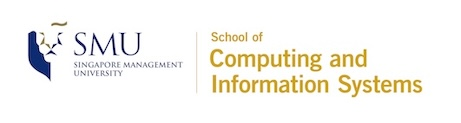

<table class="table table-bordered">
    <tr>
        <th style="text-align:center;"><h1>COR-IS1704</h1><h2>A Gentle Introduction to Computational Efficiency</h2></th>
    </tr>
</table>

## Learning Outcomes

At the end of this lesson, you should be able to:
<ul>
    <li>Understand what is an algorithm.
    <li>Count the number of basic operations an algorithm takes.
    <li>Understand the concept of computational efficiency.
    <li>Understand constant, linear, and polynomial time algorithms.
    <li>Identify the dominant term in an expression.
    <li>Use Big O notation to describe the complexity of an algorithm.
</ul>

## I. Motivation

So far, we have been focusing on learning how to write logically correct code, i.e., code that can produce the expected, correct output. While writing logically correct code is the first step towards becoming a competent programmer, another important aspect of writing high-quality code that we have not touched upon is the <b>efficiency</b> of code. 

Sometimes two pieces of code with different logic can both correctly complete the same task, but their efficiency may be different. When handling a large amount of input or data, code that runs more efficiently <b>can save much time and computational resource</b>, which might incur less energy consumption on personal computers and servers.

Specifically, here we are interested in the <b>algorithmic</b> efficiency of code. 

## II. Algorithms

To understand algorithmic efficiency, we need to first understand what is an <b>algorithm</b>. The definition of an algorithm given in Wikipedia is the following:

<h4><i>"An algorithm is a finite sequence of mathematically rigorous instructions, typically used to solve a class of specific problems or to perform a computation."</i></h4>

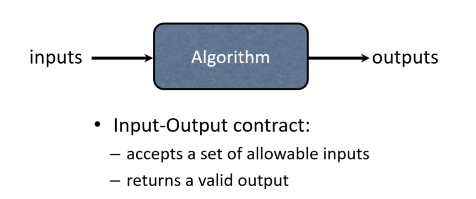

The diagram above illustrates one way to think about algorithms. An algorithm takes in certain inputs and produces certain outputs. However, different from a function (which also transforms certain inputs into valid outputs), an algorithm describes a general mathematical procedure to perform the computation rather than the actual implementation. The same algorithm can be implemented in different programming languages.

It is also important to note that an algorithm is typically used to solve a <b>class</b> of similar problems rather than a specific problem. 

For example, consider the problem of finding the largest number among a sequence of numbers. A specific problem of this kind might be "to find the larger number between two numbers", which can be solved by the function below:

In [ ]:
def find_larger_number(n1, n2):
    if n1 >= n2:
        return n1
    else:
        return n2

However, if we have three numbers, the code above cannot be used. We can revise the code as follows to handle three numbers:

In [ ]:
def find_largest_number_among_three(n1, n2, n3):
    if n1 >= n2 and n1 >= n3:
        return n1
    elif n2 >= n1 and n2 >= n3:
        return n2
    else:
        return n3

But the code above for three numbers still cannot be used when we have four or more numbers. To handle the general problem of "finding the largest number among a sequence of numbers", we need an <b>algorithm</b> that can be applied no matter how many numbers there are in the sequence. For example, one possible algorithm for finding the largest number among a list of numbers is as follows:

In [ ]:
# Solution 1
# ----------

def find_largest_number_1(num_list):
    for num in num_list:
        # Check whether this number is larger than or equal to all numbers in the list. If so, then return this number.
        if larger_than_or_equal_to_all(num, num_list):
            return num
    # The code above is guaranteed to return one of the numbers in num_list. 
    # But in the case when num_list is empty, we return None.
    return None
    
def larger_than_or_equal_to_all(n, n_list):
    # This function returns True if n is larger than or equal to all numbers in n_list, and False otherwise.
    for m in n_list:
        if m > n:
            return False
    return True

However, you may recall that there is another way, i.e., another <b>algorithm</b>, of finding the largest number among a list of numbers, as shown below:

In [ ]:
# Solution 2
# ----------

def find_largest_number_2(num_list):
    if num_list == []:
        return None
    
    largest = num_list[0]
    # For each number in the list, if it is larger than the largest number found before that point, 
    # update the largest number. 
    for num in num_list:
        if num > largest:
            largest = num
    return largest

If you test both `find_largest_number_1` and `find_largest_number_2`, you will see that they both work correctly. However, is one faster than the other? Let us give it a try. 

Run the following code snippets. We have created a function called `calculate_and_display_execution_time` to calculate and display the execution time taken by the function passed as argument. <br>
Compare the time needed for `find_largest_number_1` and for `find_largest_number_2` to return the largest number. Do you notice a difference?

In [ ]:
import time

# This function calculates and displays the execution time due to the line 11 
# (execution of a given function)
def calculate_and_display_execution_time(num_list, given_funct):
    
    # Start time
    start_time = time.time()
    
    # Call the function
    largest_number = given_funct(num_list)
    
    # End time
    end_time = time.time()

    # Calculate the execution time
    execution_time = end_time - start_time

    # Print the result and execution time
    print("Largest number:", largest_number)
    print("Execution time:", execution_time, "seconds")

In [ ]:
num_list = list(range(20000))

In [ ]:
# Execution time taken by the function find_largest_number_1:
calculate_and_display_execution_time(num_list, find_largest_number_1)

In [ ]:
# Execution time taken by the function find_largest_number_2:
calculate_and_display_execution_time(num_list, find_largest_number_2)

We notice that `find_largest_number_1` clearly takes longer to finish than `find_largest_number_2`. Why? 

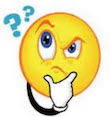

If we closely examine the two algorithms, we can see that intuitively `find_largest_number_2` goes through all the numbers in `num_list` once, performing `l` times of comparison between two numbers, where `l` is the length of `num_list`. <br>

In comparison, `find_largest_number_1` also goes through all the numbers in `num_list` but for each of these numbers the function `larger_than_or_equal_to_all` is called, which also goes through all the numbers in `num_list`. If the length of `num_list` is `l`, then the function `larger_than_or_equal_to_all` can be called up to `l` times, which means in total we may perform the comparison operation `l * l` times. <br>

When `l` is large (such as in the example above when `l` is 20,000), `l * l` is much larger than `l`, resulting in much longer execution time for `find_largest_number_1` than `find_largest_number_2`.

### Note: Time Complexity vs. Space Complexity

You may notice that we have been talking about the `running time` of different algorithms. This is only one aspect of algorithmic efficiency. Another aspect of algorithmic efficiency is regarding the `amount of memory space` needed by the algorithm. For example, how many variables need to be created when implementing the algorithm? However, in this course we will only focus on time complexity.

## III. Counting Operations to Measure Efficiency

To formalize the intuition above about the efficiency of the two algorithms (and in general to mathematically rigorously analyze the efficiency of any algorithm for any problem), we can `count the number of operations` of an algorithm in terms of its input size. Specifically, let us consider the following types of basic operations:
<ul>
    <li>Variable assignment: assigning a value to a variable, including updating the value of a variable
    <li>Arithmetic operations: performing basic arithmetic operations such as addition and multiplication
    <li>Comparison: comparing two numbers
    <li>List or string indexing: retrieving an element of a list, or a character in a string using its index  
</ul>

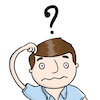

Now let us count the number of such basic operations in terms of the length of the given number list for `find_largest_number_1`. For convenience, we copy the two functions below.

In [ ]:
def find_largest_number_1(num_list):
    for num in num_list:
        # Check whether this number is larger than or equal to all numbers in the list. If so, then return this number.
        if larger_than_or_equal_to_all(num, num_list):
            return num
    # The code above is guaranteed to return one of the numbers in num_list. 
    # But in the case when num_list is empty, we return None.
    return None
    
def larger_than_or_equal_to_all(n, n_list):
    # This function returns True if n is larger than or equal to all numbers in n_list, and False otherwise.
    for m in n_list:
        if m > n:
            return False
    return True

Let us first examine `find_largest_number_1`. Let `l` represent the length of `num_list` in Line 1 above. We can see that in the function `find_largest_number_1`, we need to call the function `larger_than_or_equal_to_all` `l` times, so let us now switch to examine the number of operations performed by `larger_than_or_equal_to_all`. 

Let us still use `l` to represent the length of the parameter `n_list` of `larger_than_or_equal_to_all`. The basic operations this function performs are the comparison operations in Line 13. However, how many times Line 13 has to be executed depends on the values of the numbers in the list. If, say, the first number in `n_list` is larger than `n`, then we only need to execute Line 13 once. But if none of the numbers in `n_list` is larger than `n`, then we will need to execute Line 13 `l` times. In general, the number of times Line 13 has to be executed ranges from 1 to `l`.

What people generally do in this case is to consider the <b>worst case</b> scenario and count the operations in such worst case scenarios. If we consider the worst case, then we can see that `larger_than_or_equal_to_all` performs number comparison `l` times.

Now if we switch back to the function `find_largest_number_1`, we can see that in the worst case, the function needs to perform number comparison `l * l` or $l^2$ times. 

Because `l` is the size of the input, we say this algorithm is a <b>quadratic time</b> algorithm, i.e., its running time scales quadratically with its input size. 

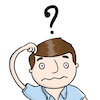

Now let us count the number of basic operations in terms of the length of the given number list for `find_largest_number_2`. For convenience, we copy the function below.

In [ ]:
def find_largest_number_2(num_list):
    if num_list == []:
        return None
    largest = num_list[0]
    # For each number in the list, if it is larger than the largest number found before that point, 
    # update the largest number. 
    for num in num_list:
        if num > largest:
            largest = num
    return largest

We can ignore the scenario when `num_list` is empty. Then starting from Line 4, we can see that the function first performs one operation of variable assignment. Then if we move to Line 7 and Line 8, we can see that Line 8 will definitely be executed `l` times (where `l` is the length of `num_list`). How many times Line 9 will be executed depends on the values of the numbers in `num_list`, but again, if we consider the worst case scenario, then we will need to execute Line 9 `l-1` times. (Note that the first number in `num_list` will never be larger than the initial value of `largest`.) 

In total, the function will perform `2l` basic operations (one assignment in Line 4, `l` comparisons in Line 8, and `l-1` assignments in Line 9), when `num_list` is not empty. 

Because $2l$ is a linear function of $l$, we say this algorithm is a `linear time algorithm`, i.e., its running time scales linearly with its input size.

If we compare $l^2$ and $2l$, the numbers of operations of the two algorithms above, we can clearly see that when $l$ is larger than 2, $l^2$ is larger than $2l$, which means `find_largest_number_1` takes more time to run than `find_largest_number_2`. In general, we are interested in comparing the efficiency of two algorithms performing the same task when their input size is huge. In mathematical terms, it is called the <b>asymptotic behavior</b> of an algorithm.

For example, suppose an algorithm requires $2n + 3$ operations, where $n$ is the input size, when $n$ is very large, the constants $2$ and $3$ can be ignored. Similarly, suppose another algorithm requires $n^2 + n$ operations, as $n$ grows, the proportion of operations from the term $n$ in the formula is getting smaller and smaller compared with the proportion of operations from the term $n^2$.

In general, we care only about the <b>dominant</b> term in the formula of the number of operations. We will talk more about this below.

## IV. Complexity

We have explained how we can count the number of basic operations in an algorithm to measure its efficiency. This measurement is formally called the <b>complexity</b> of an algorithm. 

People typically use a notation called the <b>Big-O</b> notation to represent the worst-case complexity of an algorithm. The table below shows a number of different complexity levels. The first row is the most efficient (and therefore least complex) kind of algorithms, while the last row is generally considered the least efficient (and therefore most complex) kind of algorithms that we discuss in this course.

|     | Big O | Remarks |
| :- | :- | :- |
| constant | O(1) | runs in constant time, not affected by input size $n$|
| linear | O($n$) | running time is proportional to the input size $n$; when $n$ doubles, the number of operations also doubles|
| polynomial | O($n^k$) | when $n$ doubles, the number of operations scales by $2^k$ (quadruples when $k = 2$) | 
| exponential | O($k^n$) | when $n$ increases by 1, the number of operations scales by $k$ (doubles when $k = 2$) |

(*) Note that exponential complexity analysis will not be tested.

When the number of operations contains multiple terms, the <b>dominant</b> term determines the complexity of the algorithm.

For example, if an algorithm takes $2^n + n^2$ operations to run, the term $2^n$ is the dominant term. To see why this is the case, we can see the following table:

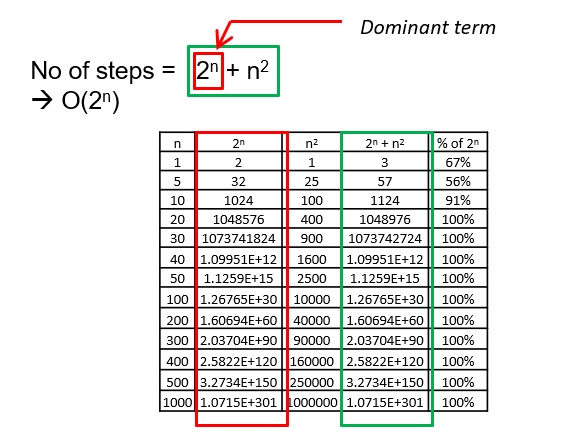

We can see that as $n$ grows much bigger, the number of operations resulting from the term $2^n$ will determine the total number of operations, as illustrated by the last column on the right.

In general, you can use the order of complexity shown in the previous table to determine which term in the dominant term.

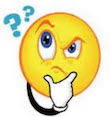

What is the worst-case complexity of the Python operator <code>in</code> used for checking if an element is in a list/tuple, or a character is in a string?

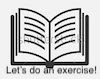

### Exercise 1

Take a look at the following code snippet and see if you can count the number of comparison operations and the number of assignment operations needed to run the program, when the input size is $n$.

In [ ]:
# This function returns the largest number among the first 10 numbers in a 
# list of numbers. It is assumed that the list of numbers given (as a parameter) 
# has at least 10 elements.
def find_largest_in_first_ten(num_list):
    max_num = num_list[0]
    for i in range(1, 10):
        if num_list[i] > max_num:
            max_num = num_list[i]
    return max_num

Write your solution below:

In [ ]:
# Solution
# --------

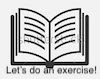

### Exercise 2

Figure out what the dominant term is in each of the expresions below, which gives you the Big-O notation for each expression.

(a) $n + 10$

(a) $3n^3 - 27n^2 + 9n + 10$

(b) $n^2 + 9n$

(c) $2^n + n^4$

Write your solution below:

In [ ]:
# Solution
# --------

### Acknowledgments

Part of the content is borrowed from or inspired by the following materials:

<li>A Gentle Introduction to Algorithm Complexity Analysis (https://discrete.gr/complexity/)
<li>Materials from Computational Thinking (AY2023-24 Term 2)